In [4]:
#2. Import Libraries:

In [6]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 2.9 MB/s eta 0:00:36
    --------------------------------------- 1.6/101.7 MB 2.9 MB/s eta 0:00:35
    --------------------------------------- 2.4/101.7 MB 3.0 MB/s eta 0:00:34
   - -------------------------------------- 2.9/101.7 MB 3.1 MB/s eta 0:00:33
   - -------------------------------------- 3.7/101.7 MB 3.1 MB/s eta 0:00:32
   - -------------------------------------- 4.5/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 5.0/101.7 MB 3.2 MB/s eta 0:00:30
   -- ------------------------------------- 5.8/101.7 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 6.6/101.7 MB 3.3 MB/s eta 0:00:29
   -- ------------------------------------- 7.3/101.7 MB 3.3 MB/s eta 0:00:29
   --- ------------------------------------ 8.1/101.7 MB 3.4 MB/s eta 0:00:28


In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Load Dataset:

In [8]:
df = pd.read_csv("cleaned_merged_heart_dataset.csv")

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [12]:
df.shape

(1888, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,54.354343,0.688559,1.135593,131.549258,246.855403,0.148305,0.597458,149.424258,0.331568,1.053761,1.421610,0.731462,2.662606,0.517479
std,9.081505,0.463205,1.103852,17.556985,51.609329,0.355496,0.638820,23.006153,0.470901,1.161344,0.619588,1.015735,1.249924,0.499827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.750000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


In [13]:
#Define Features and Target:

In [14]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
#Train-Test Split:

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#Feature Scaling:

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
#Models:
#1 Logistic Regression:

In [20]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7248677248677249
              precision    recall  f1-score   support

           0       0.78      0.63      0.69       188
           1       0.69      0.82      0.75       190

    accuracy                           0.72       378
   macro avg       0.73      0.72      0.72       378
weighted avg       0.73      0.72      0.72       378



In [21]:
#2 Support Vector Machine (SVM):

In [22]:
svm_model = SVC(kernel="rbf")

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.91005291005291
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       188
           1       0.92      0.89      0.91       190

    accuracy                           0.91       378
   macro avg       0.91      0.91      0.91       378
weighted avg       0.91      0.91      0.91       378



In [23]:
#3 Random Forest:

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.955026455026455
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       188
           1       0.96      0.95      0.95       190

    accuracy                           0.96       378
   macro avg       0.96      0.96      0.96       378
weighted avg       0.96      0.96      0.96       378



In [25]:
#4 XGBoost:

In [26]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9417989417989417
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       188
           1       0.94      0.95      0.94       190

    accuracy                           0.94       378
   macro avg       0.94      0.94      0.94       378
weighted avg       0.94      0.94      0.94       378



In [27]:
#Confusion Matrix Visualization:

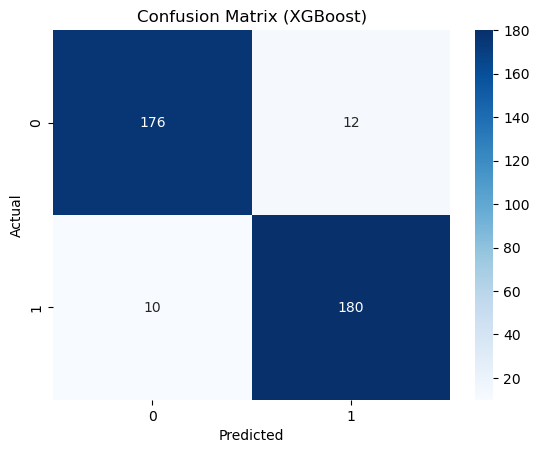

In [28]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
#Compare Model Performance:

In [30]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.724868
1                  SVM  0.910053
2        Random Forest  0.955026
3              XGBoost  0.941799


In [31]:
#Predict Disease for New Patient:

In [34]:
sample_patient = [[63,1,3,145,233,1,0,150,0,2.3,0,0,1]]

sample_patient = scaler.transform(sample_patient)

prediction = xgb_model.predict(sample_patient)

if prediction[0] == 1:
    print("High probability of heart disease")
else:
    print("Low probability of heart disease")

High probability of heart disease
